## Student performance indicator ##

## Life cycle of Machine Learning Project

* Understanding the problem statement
* Data Collection
* Data Checks to perform
* Exploratory data analysis
* Data preprocessing 
* Model Training
* Choose the best model

## 1) Problem Statement
* This project understands how the student's performance (test score) is affected by other variables such as Gender, Ethnicity, Parental level of education, Lunch and test preparation course.

## 2) Data Collection
* The dataset consist of 8 columns and 100 rows.

### Import Data and required packages
* importing pandas, numpy, matplotlib, seaborn and warning library.

In [8]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

Matplotlib is building the font cache; this may take a moment.


In [23]:
df = pd.read_csv("data/stud.csv")

In [29]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [11]:
df.shape

(1000, 8)

## Data Checks to peform
* Check Missing values
* Check Duplicates
* Check datatypes
* Check the number of unique values of each column
* Check statistics of dataset
* Check various categories present in the different categorical column

## 3.1 Check Missing Values

In [28]:
df.isna().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

## 3.2 Check Duplicates

In [13]:
df.duplicated().sum()

np.int64(0)

## 3.3 Check datatypes

In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


## 3.4 Check the number of unique values of each column

In [15]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

## 3.5 Check statistics 

In [17]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


## 3.6 Exploring the data

In [18]:
print("Categories in Gender:  ",end="  ")
print(df['gender'].unique)

print("Categories in race_ethnicity:  ", end="  ")
print(df['race_ethnicity'].unique())

print("Categories in parental level education:  ", end="  ")
print(df['parental_level_of_education'].unique())

print("Categories in lunch: ", end="  ")
print(df['lunch'].unique())

print("Categories in test preparation course: ", end="  ")
print(df['test_preparation_course'].unique())

Categories in Gender:    <bound method Series.unique of 0      female
1      female
2      female
3        male
4        male
        ...  
995    female
996      male
997    female
998    female
999    female
Name: gender, Length: 1000, dtype: str>
Categories in race_ethnicity:    <StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str
Categories in parental level education:    <StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str
Categories in lunch:   <StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str
Categories in test preparation course:   <StringArray>
['none', 'completed']
Length: 2, dtype: str


In [38]:
# define numerical & categorical columns
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']
string_features = [feature for feature in df.columns if df[feature].dtype == 'str']


# print columns
print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))
print('\nWe have {} string features : {}'.format(len(string_features), string_features))

We have 3 numerical features : ['math score', 'reading score', 'writing score']

We have 5 categorical features : ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']

We have 0 string features : []


## Converting stirng dtypes into object

In [35]:
string_cols= df.select_dtypes(include='string').columns
df[string_cols]= df[string_cols].astype('object')

## 3.7 Adding columns for Total Score and Average

In [39]:
df['total score']= df['math score'] + df['reading score'] + df['writing score']
df['average'] = df['total score']/3
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [40]:
reading_full = df[df['reading score']==100]['average'].count()
writing_full = df[df['writing score']==100]['average'].count()
math_full = df[df['math score']==100]['average'].count()

print(f"Students with full marks in Maths : {math_full}")
print(f"Students with full marks in writing: {writing_full}")
print(f"students with full marks in Reading: {reading_full}")

Students with full marks in Maths : 7
Students with full marks in writing: 14
students with full marks in Reading: 17


In [41]:
reading_less20 = df[df['reading score']<=20]['average'].count()
writing_less20 = df[df['writing score']<=20]['average'].count()
math_less20 = df[df['math score']<=20]['average'].count()

print(f"Students with <20 marks in Maths : {math_less20}")
print(f"Students with <20 marks in writing: {writing_less20}")
print(f"students with <20 marks in Reading: {reading_less20}")

Students with <20 marks in Maths : 4
Students with <20 marks in writing: 3
students with <20 marks in Reading: 1


# 4- Exploring Data (Visualization)
## 4.1.1 Visualize average score distribution 
* Histogram
* Kernal Distribution Function KDE

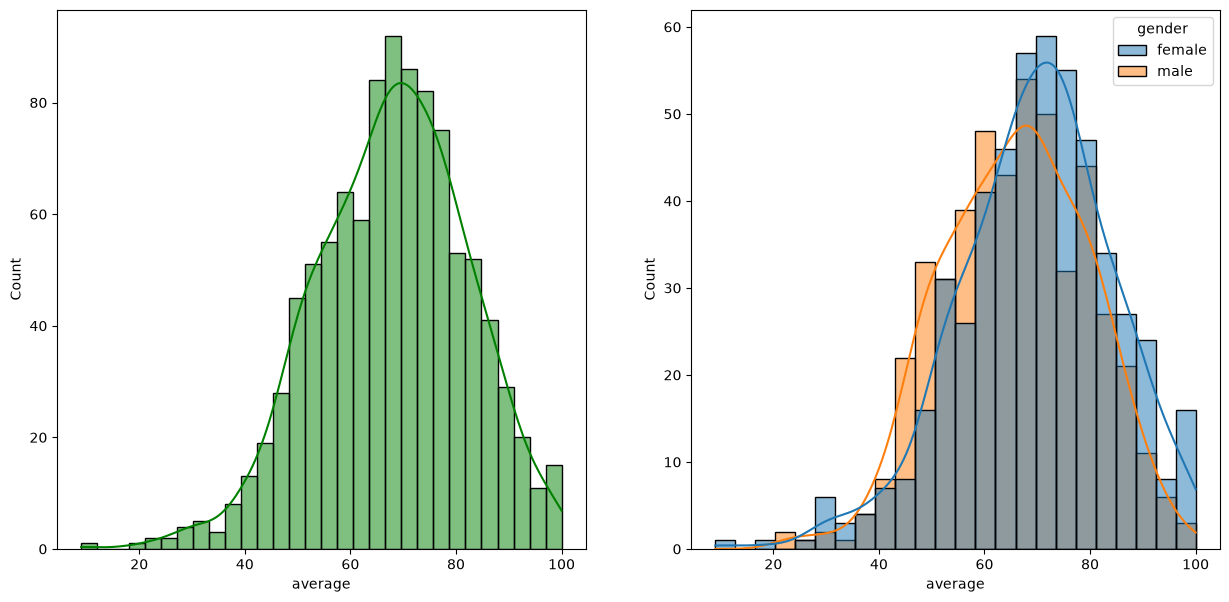

In [42]:
fig, axs = plt.subplots(1,2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=df,x='average', bins=30, kde=True, color='g')
plt.subplot(122)
sns.histplot(data=df,x='average',kde=True, hue='gender')
plt.show()

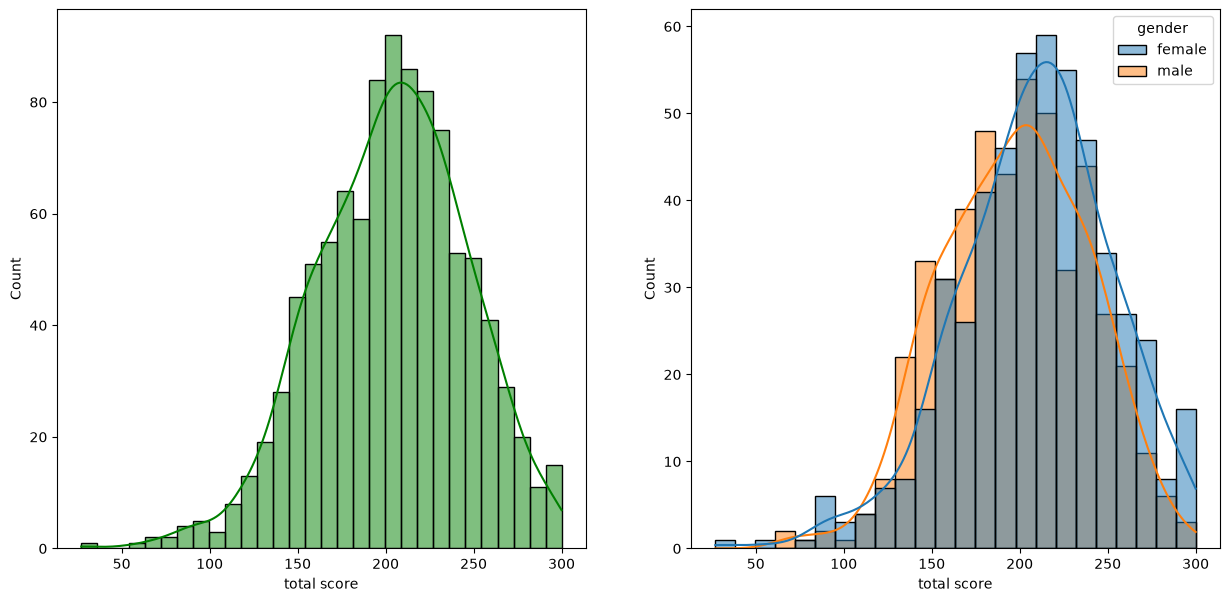

In [43]:
fig, axs = plt.subplots(1,2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=df,x='total score', bins=30, kde=True, color='g')
plt.subplot(122)
sns.histplot(data=df,x='total score',kde=True, hue='gender')
plt.show()

* female students tends to perform well than male students

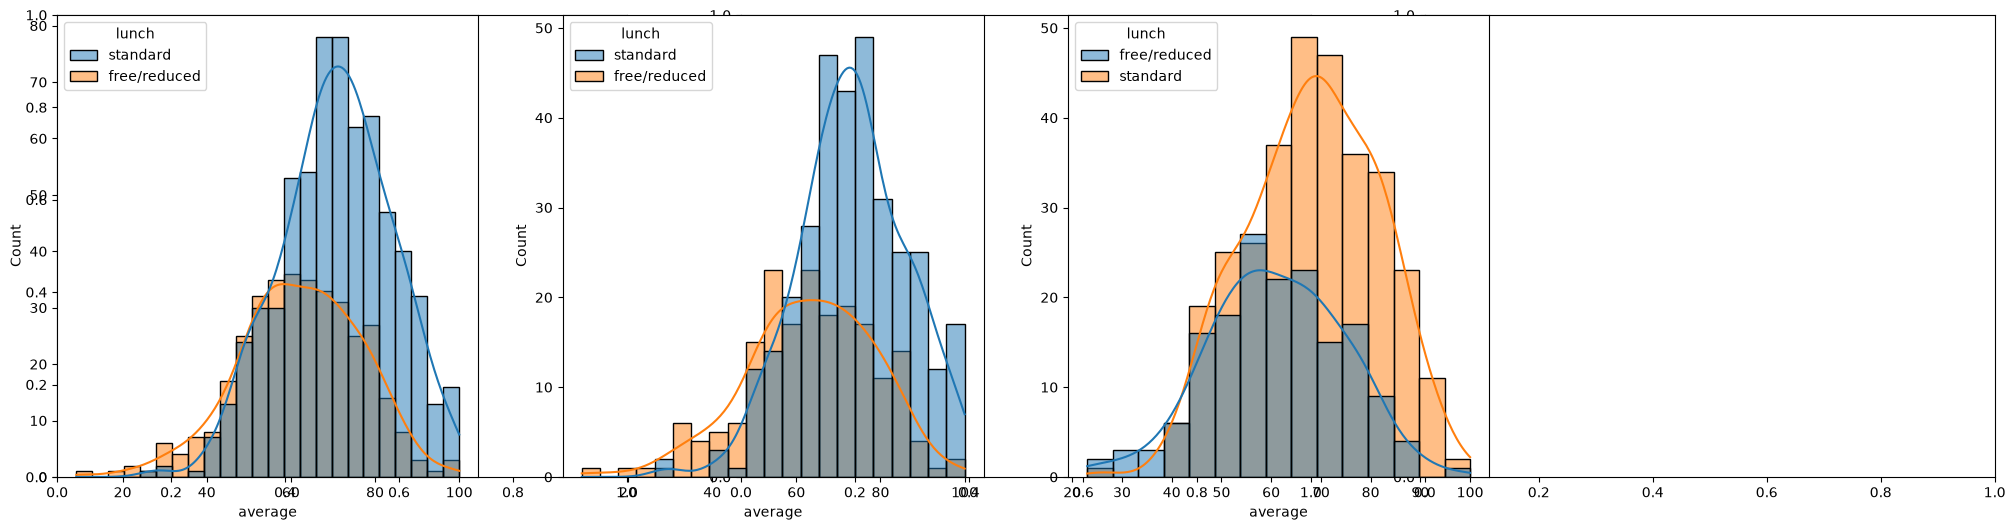

In [44]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
sns.histplot(data=df, x= 'average', kde=True, hue='lunch')
plt.subplot(142)
sns.histplot(data= df[df.gender=='female'],x= 'average', kde=True, hue='lunch')
plt.subplot(143)
sns.histplot(data=df[df.gender=='male'], x= 'average', kde=True, hue='lunch')
plt.show()

* Standard lunch helps perform well in exams.
* for male and female both 

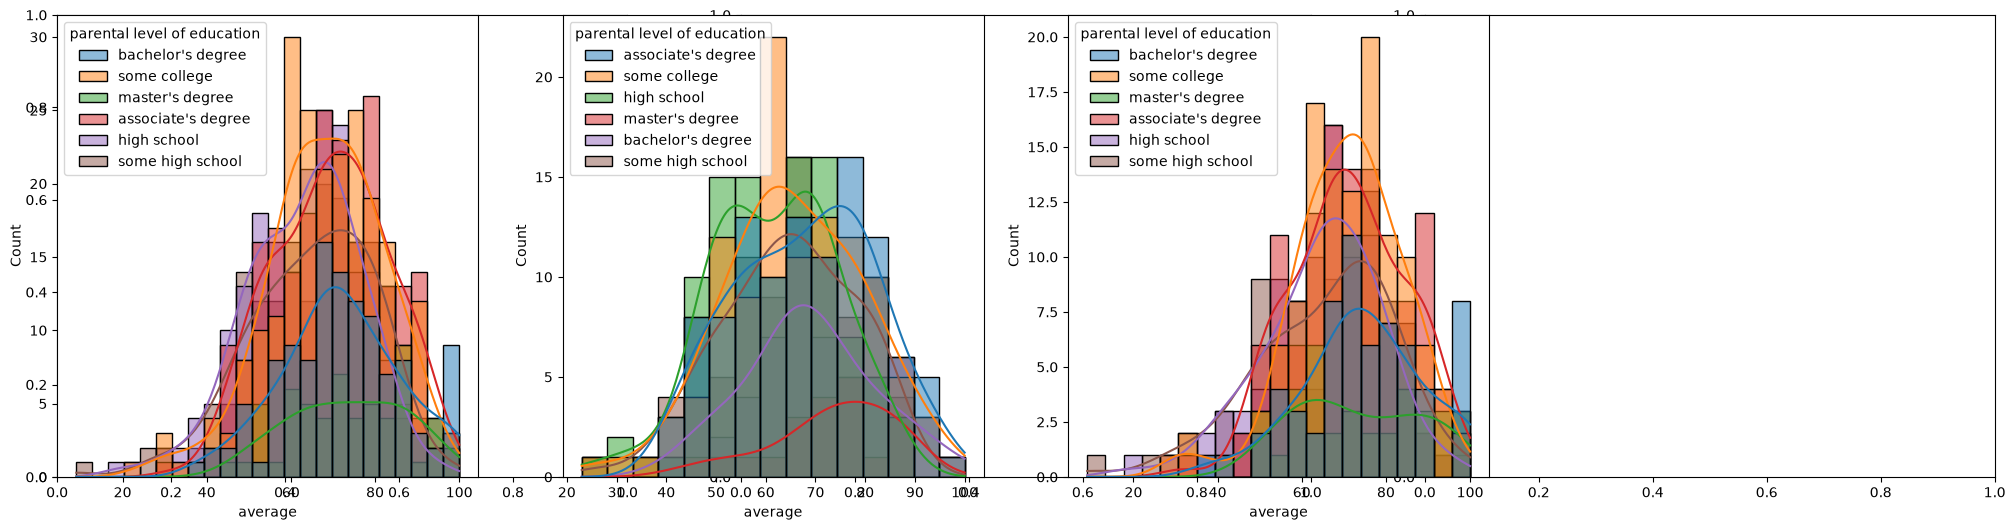

In [46]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
ax = sns.histplot(data=df, x= 'average',kde=True, hue='parental level of education')
plt.subplot(142)
ax= sns.histplot(data=df[df.gender=='male'],x= 'average', kde=True, hue='parental level of education')
plt.subplot(143)
ax = sns.histplot(data=df[df.gender=='female'],x='average',kde=True, hue='parental level of education')
plt.show()

* In general parent's education dont help students perform well in exam.
* 2nd plot shows that parents whose education level is of assosciate degree or master degree, their male child tend to perform well in exams.
* 3rd plot shows there is no effect of parent's education on female students.

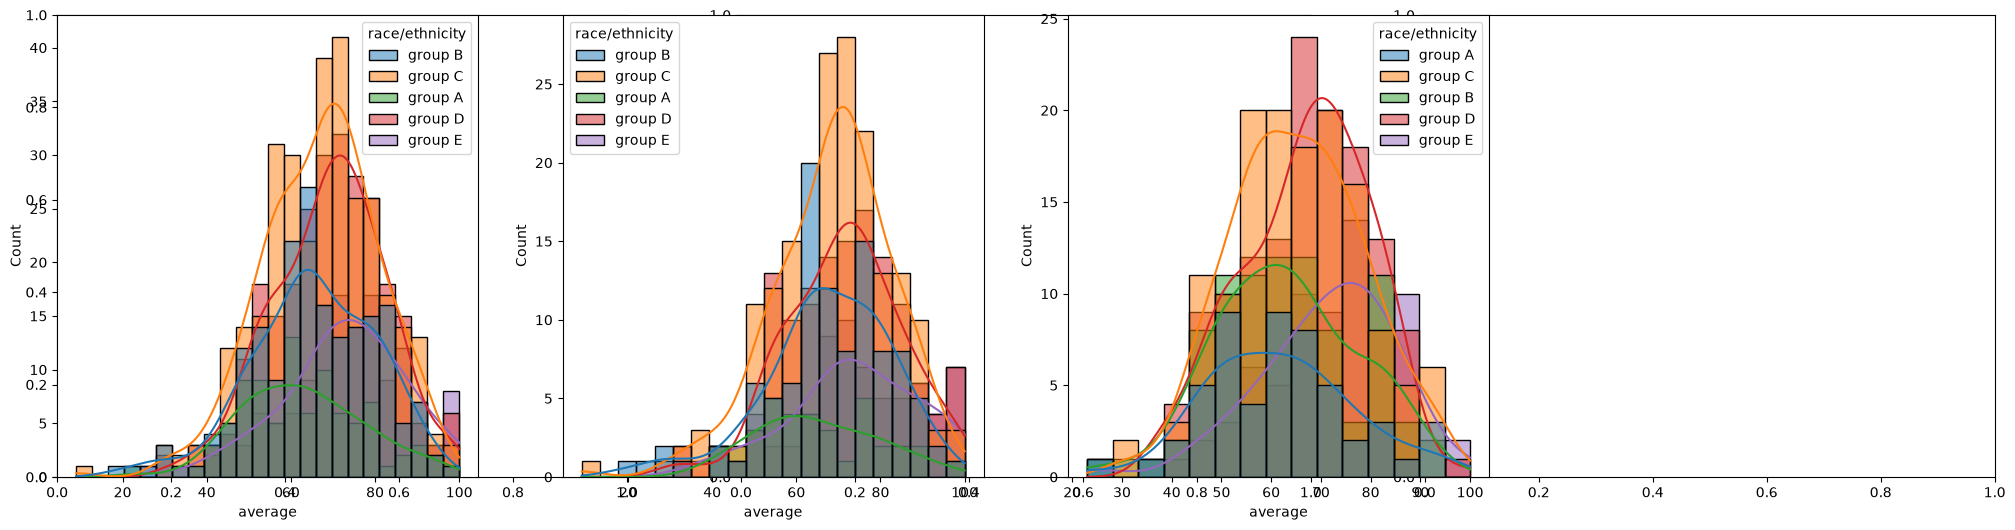

In [49]:
plt.subplots(1,3, figsize=(25,6))
plt.subplot(141)
ax = sns.histplot(data=df, x='average', kde= True, hue='race/ethnicity')
plt.subplot(142)
ax= sns.histplot(data=df[df.gender=='female'], x='average', kde=True, hue='race/ethnicity')
plt.subplot(143)
ax= sns.histplot(data=df[df.gender=='male'], x= 'average', kde=True, hue='race/ethnicity')
plt.show()

* Students of group A and B tends to perform poorly in exam.
* Group A and B perform poorly wether they are male or female

## 4.2 Maximum score of students in all three subjects

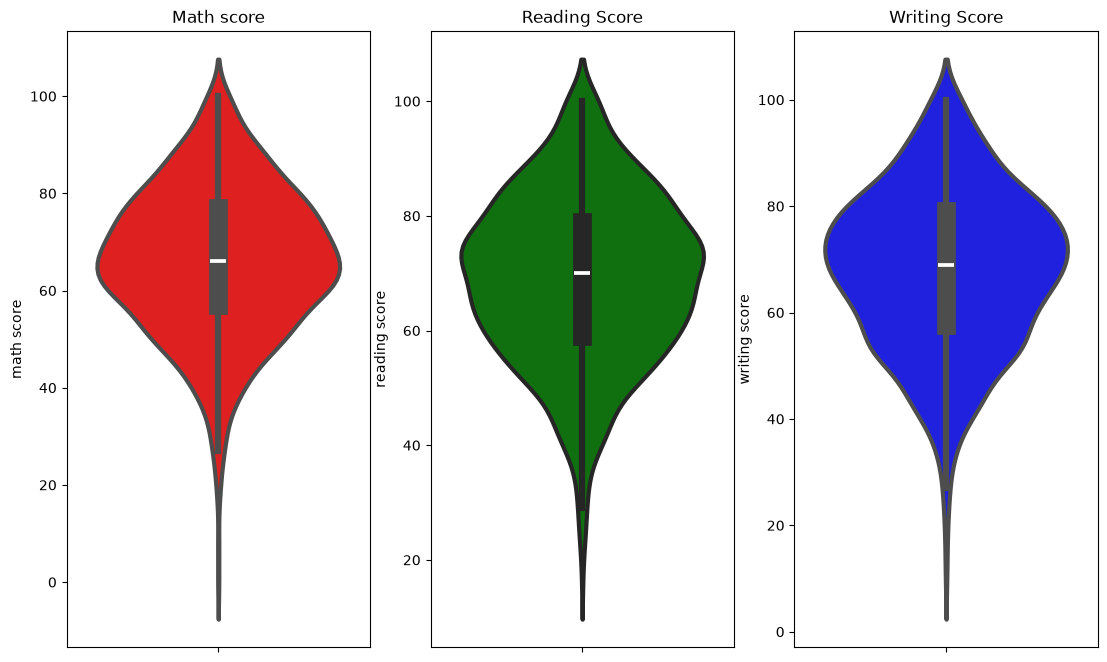

In [51]:
plt.figure(figsize=(18,8))
plt.subplot(1,4,1)
plt.title('Math score')
sns.violinplot(y='math score', data=df, color='red', linewidth=3)

plt.subplot(1,4,2)
plt.title('Reading Score')
sns.violinplot(y='reading score',data=df, color='green', linewidth=3)

plt.subplot(1,4,3)
plt.title('Writing Score')
sns.violinplot(y='writing score',data=df,color='blue', linewidth=3)
plt.show()

* Most of the students score between 60-80 in maths
* in reading and writing most oof them score between 50-80

## 4.3 Multivariate analysis using pieplot

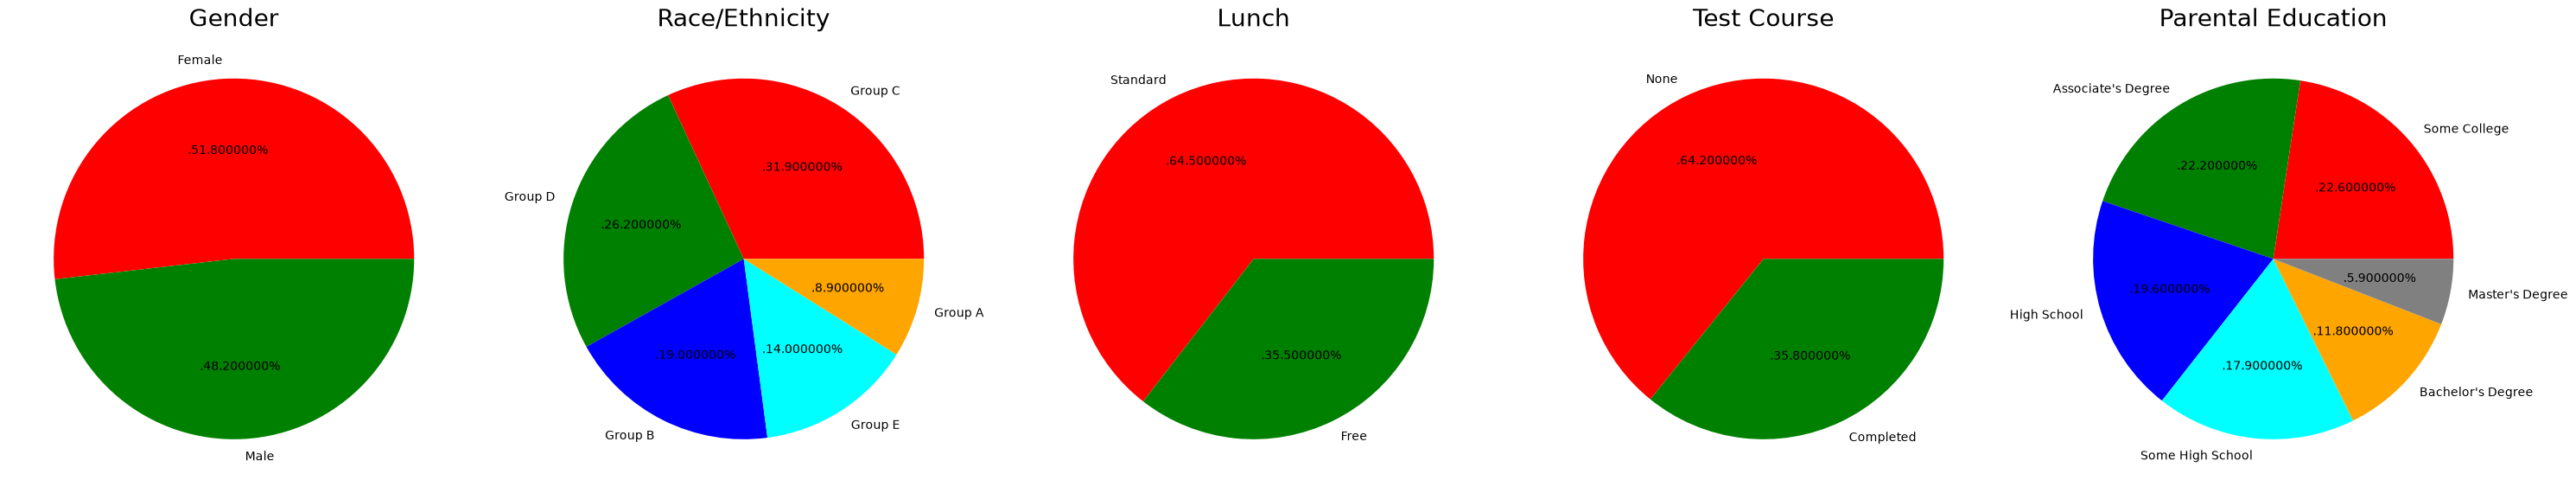

In [ ]:
plt.rcParams['figure.figsize'] = (30, 12)

plt.subplot(1, 5, 1)
size = df['gender'].value_counts()
labels = 'Female', 'Male'
color = ['red','green']


plt.pie(size, colors = color, labels = labels,autopct = '.%2f%%')
plt.title('Gender', fontsize = 20)
plt.axis('off')



plt.subplot(1, 5, 2)
size = df['race/ethnicity'].value_counts()
labels = 'Group C', 'Group D','Group B','Group E','Group A'
color = ['red', 'green', 'blue', 'cyan','orange']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Race/Ethnicity', fontsize = 20)
plt.axis('off')



plt.subplot(1, 5, 3)
size = df['lunch'].value_counts()
labels = 'Standard', 'Free'
color = ['red','green']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Lunch', fontsize = 20)
plt.axis('off')


plt.subplot(1, 5, 4)
size = df['test preparation course'].value_counts()
labels = 'None', 'Completed'
color = ['red','green']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Test Course', fontsize = 20)
plt.axis('off')


plt.subplot(1, 5, 5)
size = df['parental level of education'].value_counts()
labels = 'Some College', "Associate's Degree",'High School','Some High School',"Bachelor's Degree","Master's Degree"
color = ['red', 'green', 'blue', 'cyan','orange','grey']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Parental Education', fontsize = 20)
plt.axis('off')


plt.tight_layout()
plt.grid()

plt.show()

* Number of male and female students are almost equal
* Number of students are greatest in Group C
* Number of students who have standard lunch is greater
* Number of students who have not enrolled in any test course is greater
* Number of students whose parental education is "Some college" is greater followed closely by "Associate Degree" 

# 4.4 Feature wise visualization
## 4.4.1 Gender column
* How is distribution of Gender ?
* Is gender has any impact on student's performance ?

## Univariate analysis (Distributin of gender?)

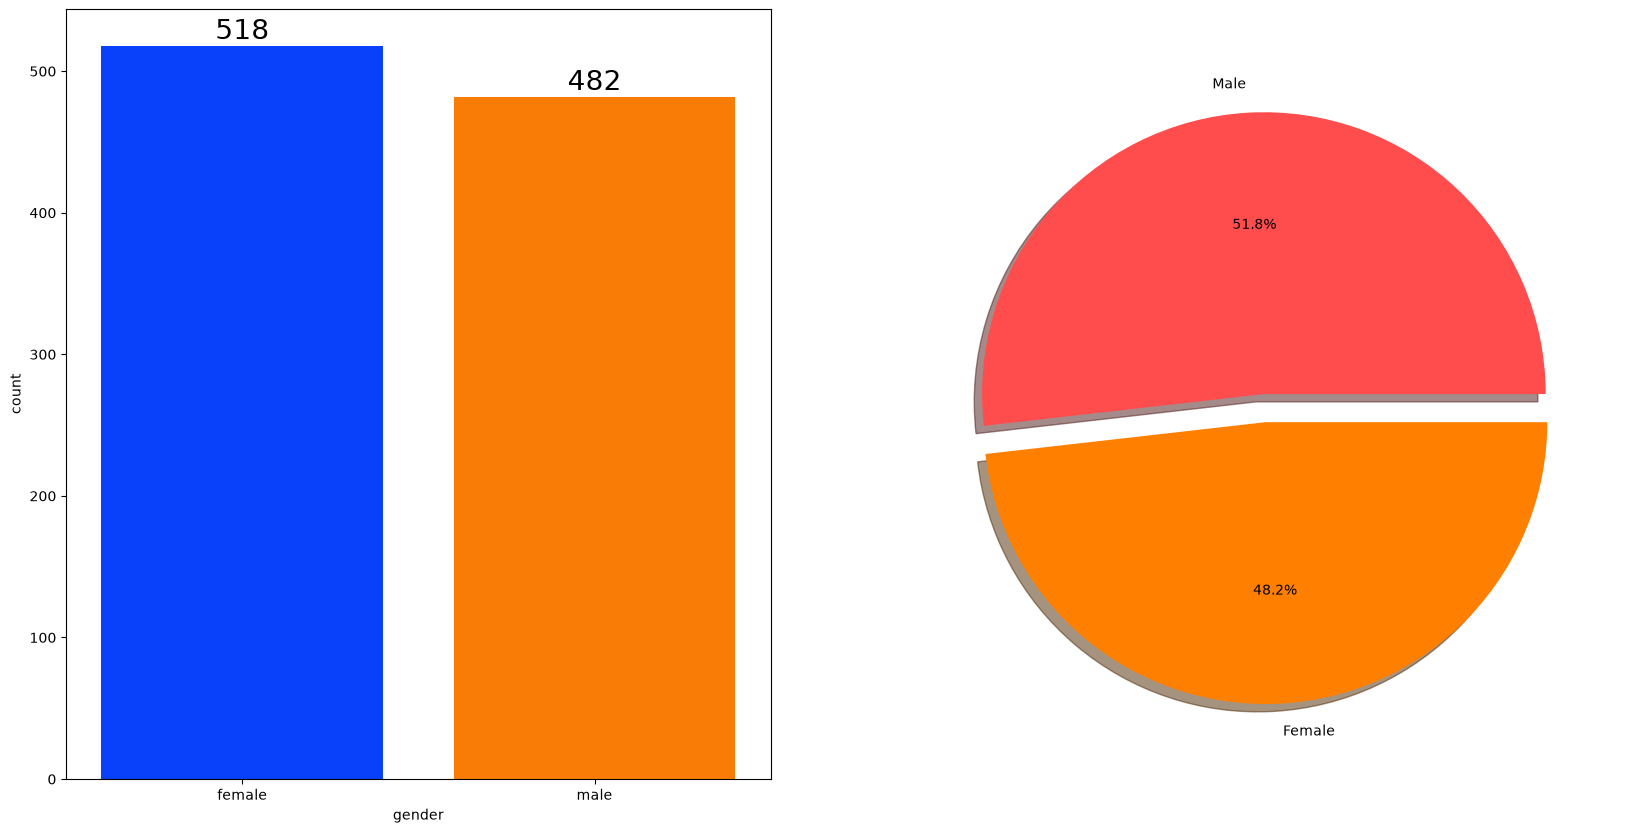

In [57]:
f,ax= plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=df['gender'],data=df, palette='bright', ax=ax[0], saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)

plt.pie(x=df['gender'].value_counts(),labels=['Male','Female'],explode=[0,0.1],autopct='%1.1f%%',shadow=True,colors=['#ff4d4d','#ff8000'])
plt.show()

* Gender has balanced data with female students are 518 (48%) and male students are 482 (52%)

## BIVARIATE ANALYSIS ( Is gender has any impact on student's performance ? )

In [63]:
gender_group = df.groupby('gender').mean(numeric_only=True)
gender_group

,math score,reading score,writing score,total score,average
gender,,,,,
female,63.633205,72.608108,72.467181,208.708494,69.569498
male,68.728216,65.473029,63.311203,197.512448,65.837483


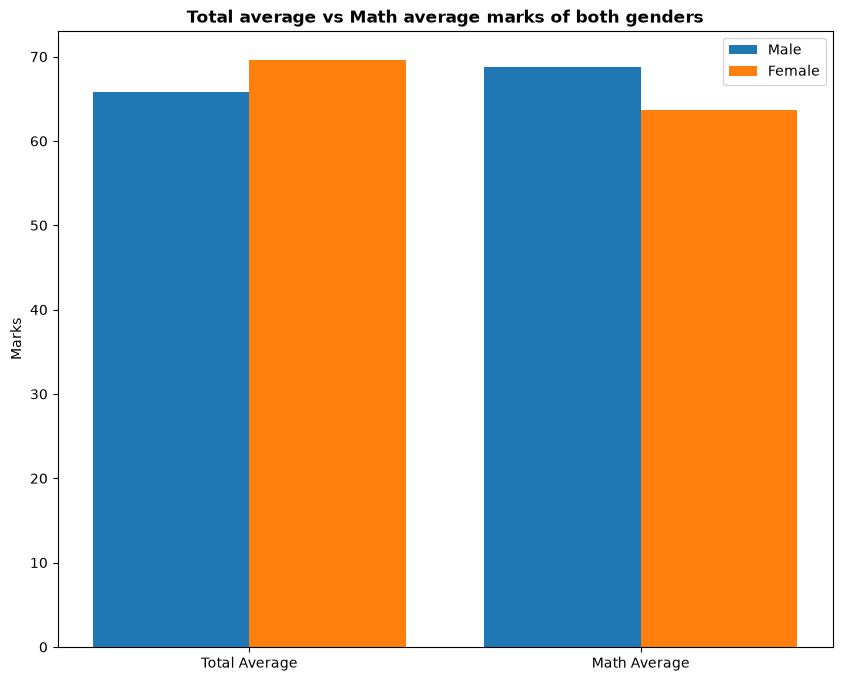

In [66]:
plt.figure(figsize=(10,8))

X = ['Total Average', 'Math Average']

female_scores = [
    gender_group.loc['female', 'average'],
    gender_group.loc['female', 'math score']
]

male_scores = [
    gender_group.loc['male', 'average'],
    gender_group.loc['male', 'math score']
]

X_axis = np.arange(len(X))

plt.bar(X_axis - 0.2, male_scores, 0.4, label='Male')
plt.bar(X_axis + 0.2, female_scores, 0.4, label='Female')

plt.xticks(X_axis, X)
plt.ylabel("Marks")
plt.title("Total average vs Math average marks of both genders", fontweight='bold')
plt.legend()

plt.show()

* On an average females have a better overall score than men.
* whereas males have scored higher in Maths.

## 4.4.2 RACE/EHNICITY COLUMN
* How is Group wise distribution ?
* Is Race/Ehnicity has any impact on student's performance ?

## UNIVARIATE ANALYSIS ( How is Group wise distribution ?)

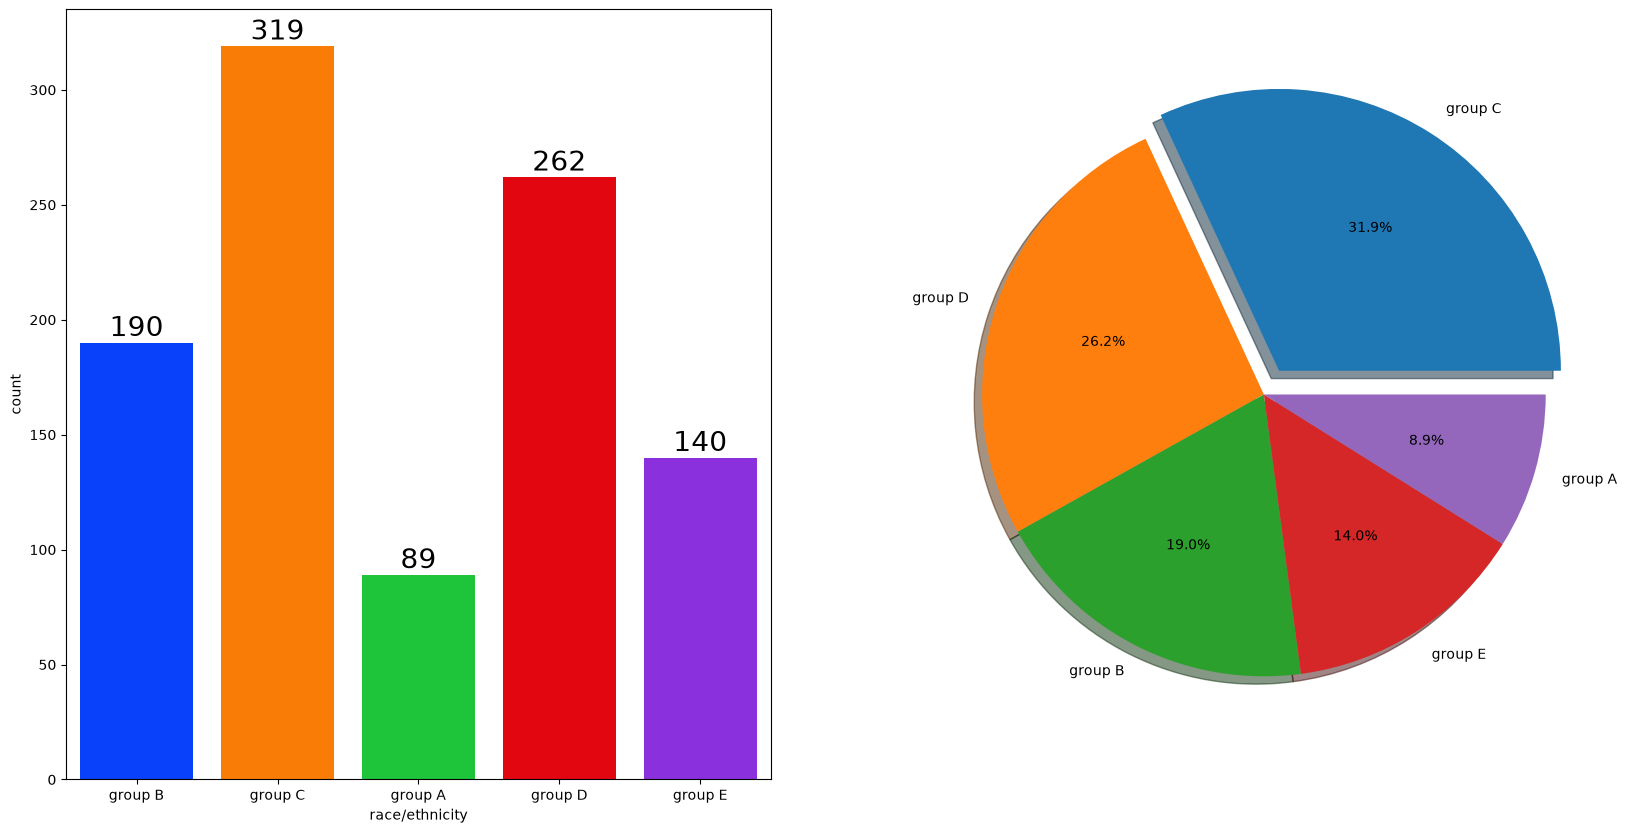

In [67]:
f,ax=plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=df['race/ethnicity'],data=df,palette = 'bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
plt.pie(x = df['race/ethnicity'].value_counts(),labels=df['race/ethnicity'].value_counts().index,explode=[0.1,0,0,0,0],autopct='%1.1f%%',shadow=True)
plt.show()   

* Most of the student belonging from group C /group D.
* Lowest number of students belong to groupA.

## BIVARIATE ANALYSIS ( Is Race/Ehnicity has any impact on student's performance ? )

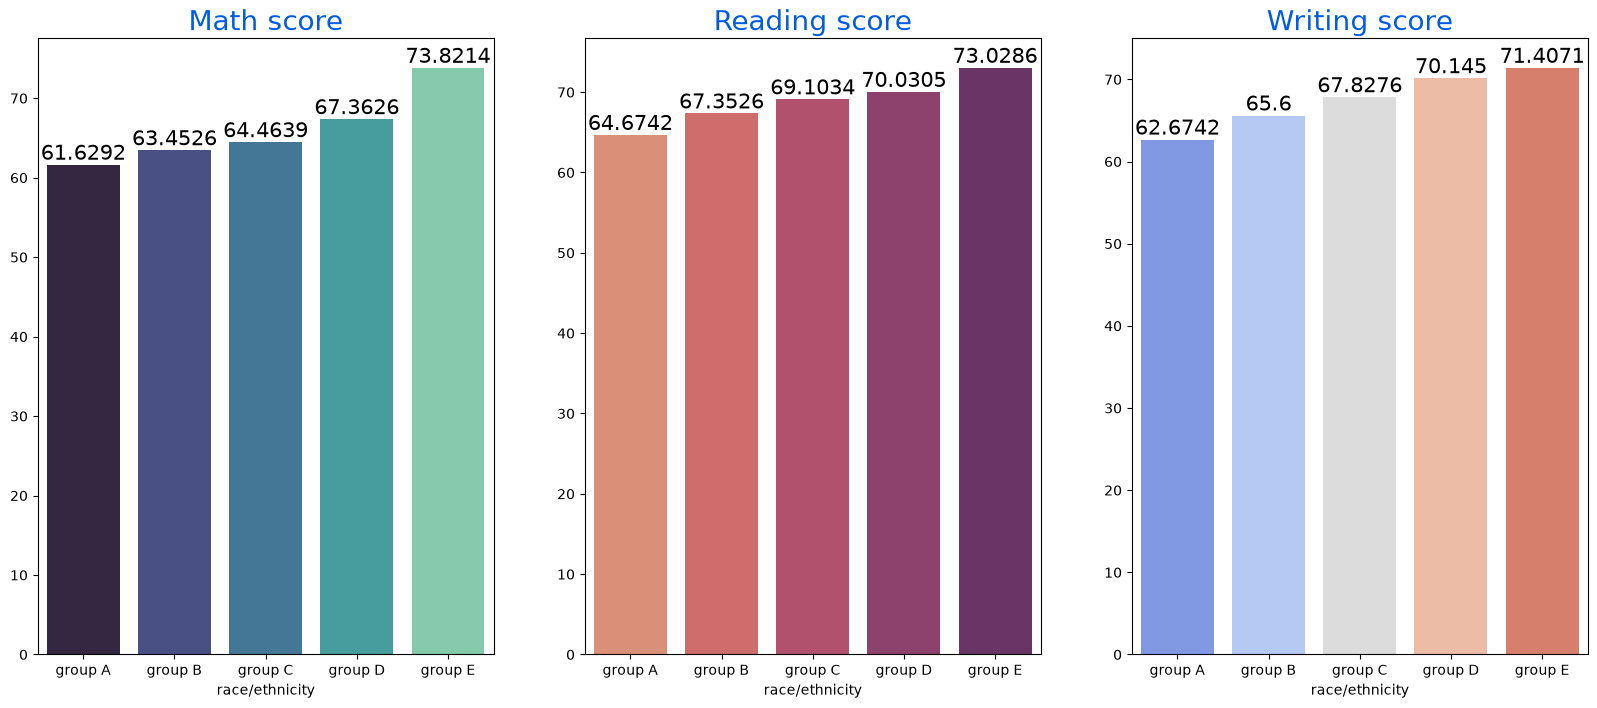

In [68]:
Group_data2=df.groupby('race/ethnicity')
f,ax=plt.subplots(1,3,figsize=(20,8))
sns.barplot(x=Group_data2['math score'].mean().index,y=Group_data2['math score'].mean().values,palette = 'mako',ax=ax[0])
ax[0].set_title('Math score',color='#005ce6',size=20)

for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=15)

sns.barplot(x=Group_data2['reading score'].mean().index,y=Group_data2['reading score'].mean().values,palette = 'flare',ax=ax[1])
ax[1].set_title('Reading score',color='#005ce6',size=20)

for container in ax[1].containers:
    ax[1].bar_label(container,color='black',size=15)

sns.barplot(x=Group_data2['writing score'].mean().index,y=Group_data2['writing score'].mean().values,palette = 'coolwarm',ax=ax[2])
ax[2].set_title('Writing score',color='#005ce6',size=20)

for container in ax[2].containers:
    ax[2].bar_label(container,color='black',size=15)

* Group E students have scored the highest marks.
* Group A students have scored the lowest marks.
* Students from a lower Socioeconomic status have a lower avg in all course subjects

## 4.4.3 PARENTAL LEVEL OF EDUCATION COLUMN
* What is educational background of student's parent ?
* Is parental education has any impact on student's performance ?

## UNIVARIATE ANALYSIS ( What is educational background of student's parent ? )

findfont: Failed to find font weight 30, now using 400.


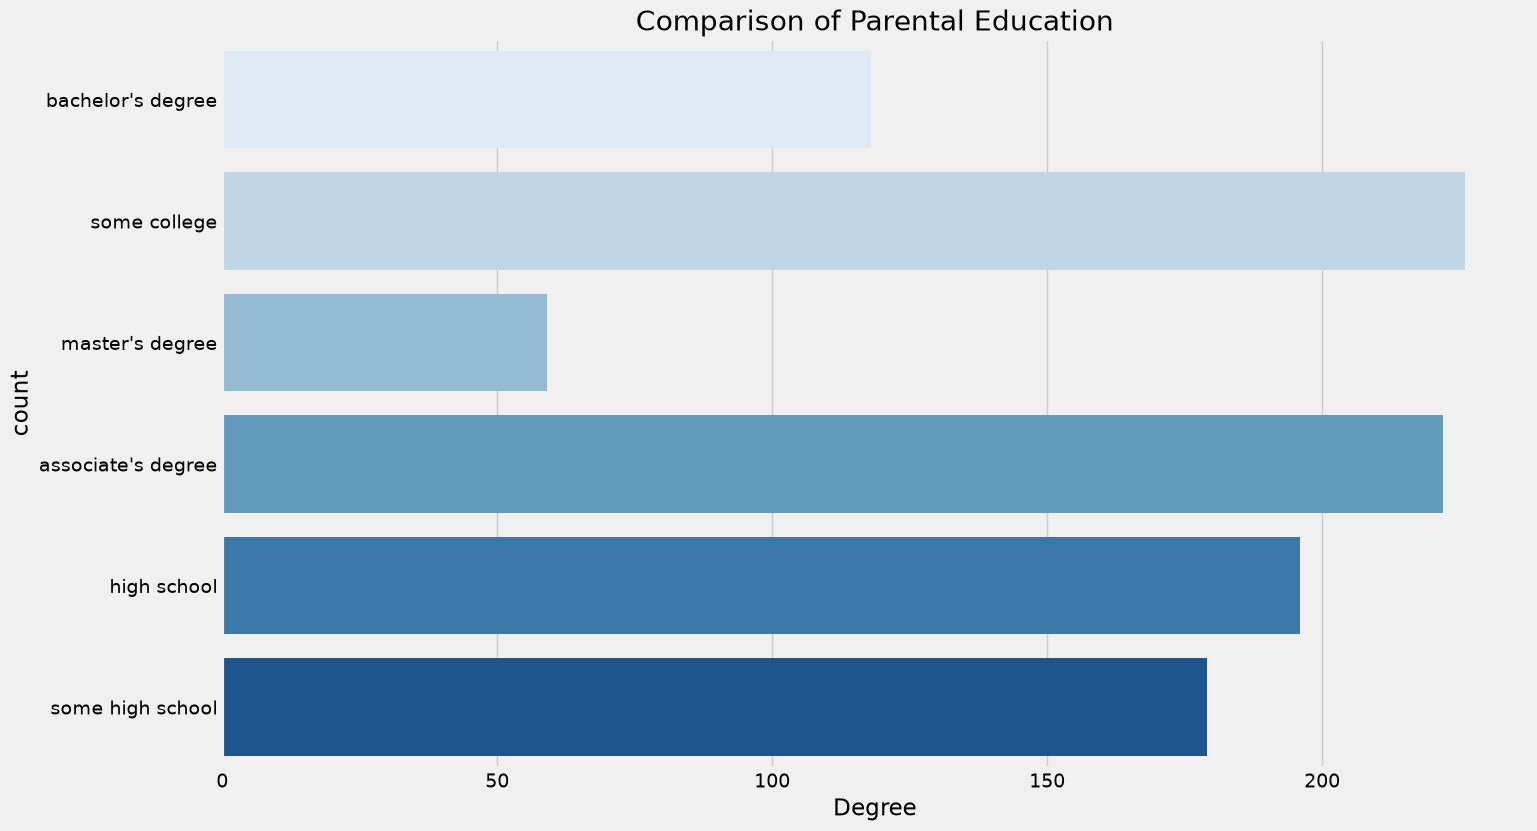

In [69]:
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('fivethirtyeight')
sns.countplot(df['parental level of education'], palette = 'Blues')
plt.title('Comparison of Parental Education', fontweight = 30, fontsize = 20)
plt.xlabel('Degree')
plt.ylabel('count')
plt.show()

* Largest number of parents are from some college.

## BIVARIATE ANALYSIS ( Is parental education has any impact on student's performance ? )

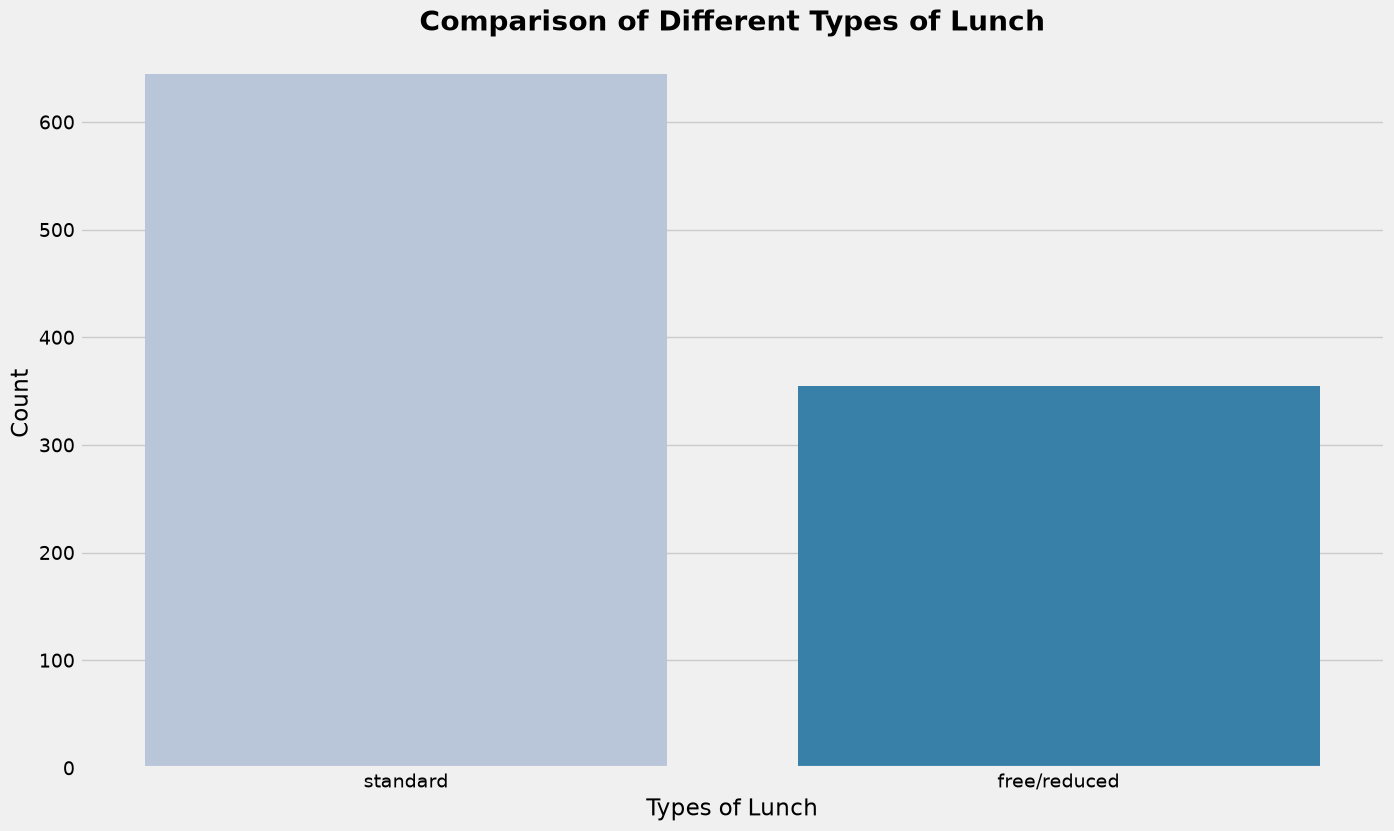

In [73]:
plt.figure(figsize=(15, 9))

sns.countplot(data=df, x='lunch', palette='PuBu', hue='lunch', legend=False)

plt.title('Comparison of Different Types of Lunch', fontsize=20, fontweight='bold')
plt.xlabel('Types of Lunch')
plt.ylabel('Count')

plt.show()

* Students being served Standard lunch was more than free lunch

### BIVARIATE ANALYSIS ( Is lunch type intake has any impact on student's performance ? )

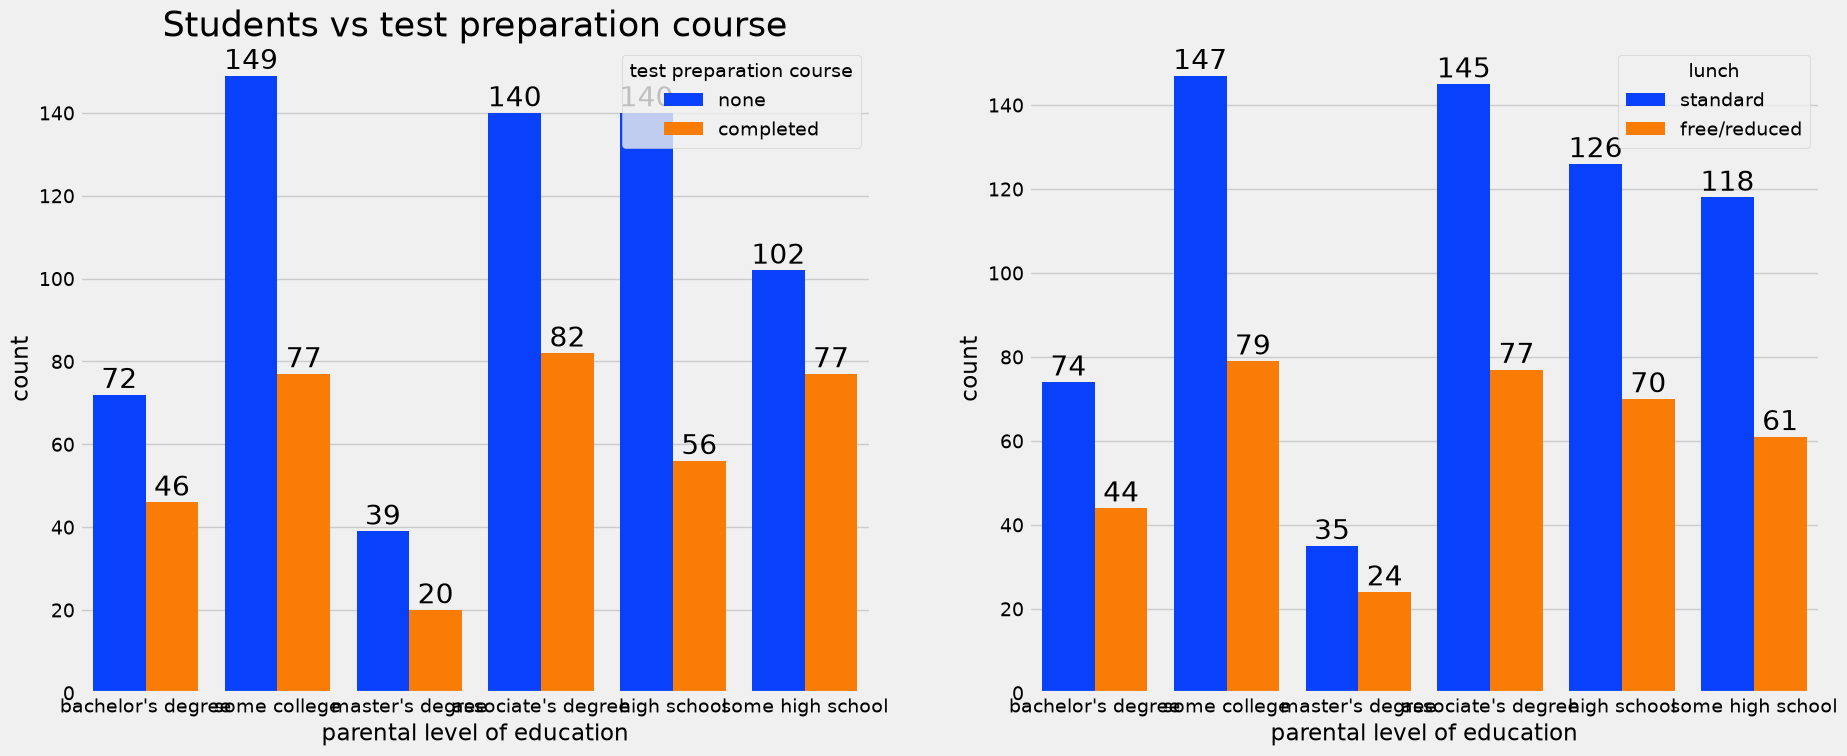

In [80]:
f,ax=plt.subplots(1,2,figsize=(20,8))
sns.countplot(x=df['parental level of education'],data=df, palette= 'bright', hue='test preparation course', saturation=0.95, ax=ax[0])
ax[0].set_title('Students vs test preparation course', color = 'black', size=25)

for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)

sns.countplot(x=df['parental level of education'],data=df,palette= 'bright', hue='lunch',saturation=0.95, ax=ax[1])
for container in ax[1].containers:
    ax[1].bar_label(container, color='black', size=20)


* Students who get Standard Lunch tend to perform better than students who got free/reduced lunch

## 4.4.5 TEST PREPARATION COURSE COLUMN
* Which type of lunch is most common amoung students ?
* Is Test prepration course has any impact on student's performance ?

### BIVARIATE ANALYSIS ( Is Test prepration course has any impact on student's performance ? )


<Axes: xlabel='lunch', ylabel='writing score'>

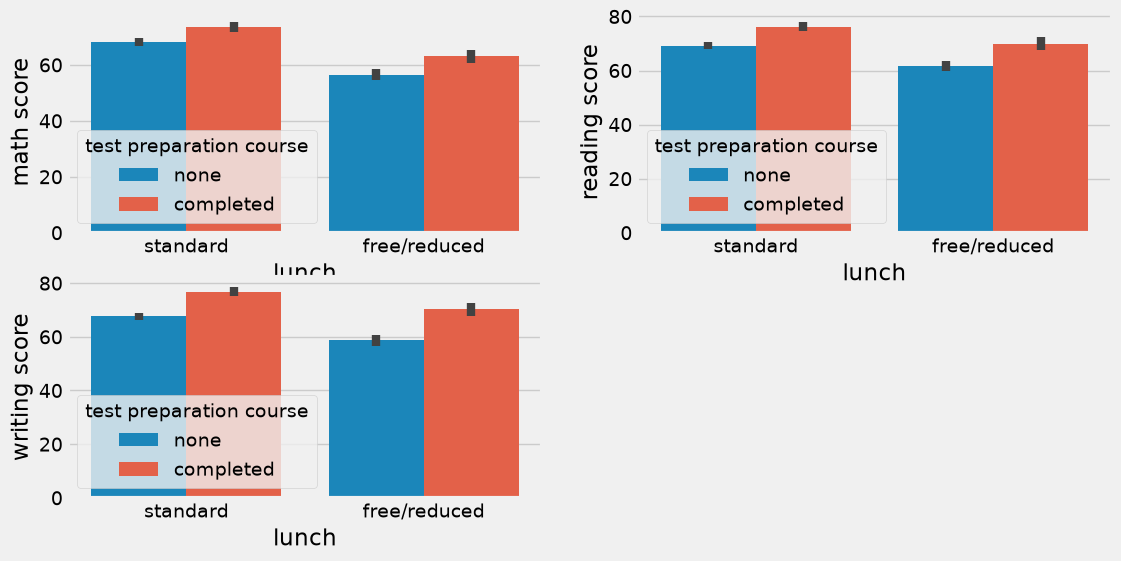

In [85]:
plt.figure(figsize=(12,6))
plt.subplot(2,2,1)
sns.barplot(x=df['lunch'], y=df['math score'], hue=df['test preparation course'])

plt.subplot(2,2,2)
sns.barplot(x=df['lunch'],y=df['reading score'], hue=df['test preparation course'])

plt.subplot(2,2,3)
sns.barplot(x=df['lunch'],y=df['writing score'], hue=df['test preparation course'])


* Students who have completed the Test Prepration Course have scores higher in all three categories than those who haven't taken the course

### 4.4.6 CHECKING OUTLIERS

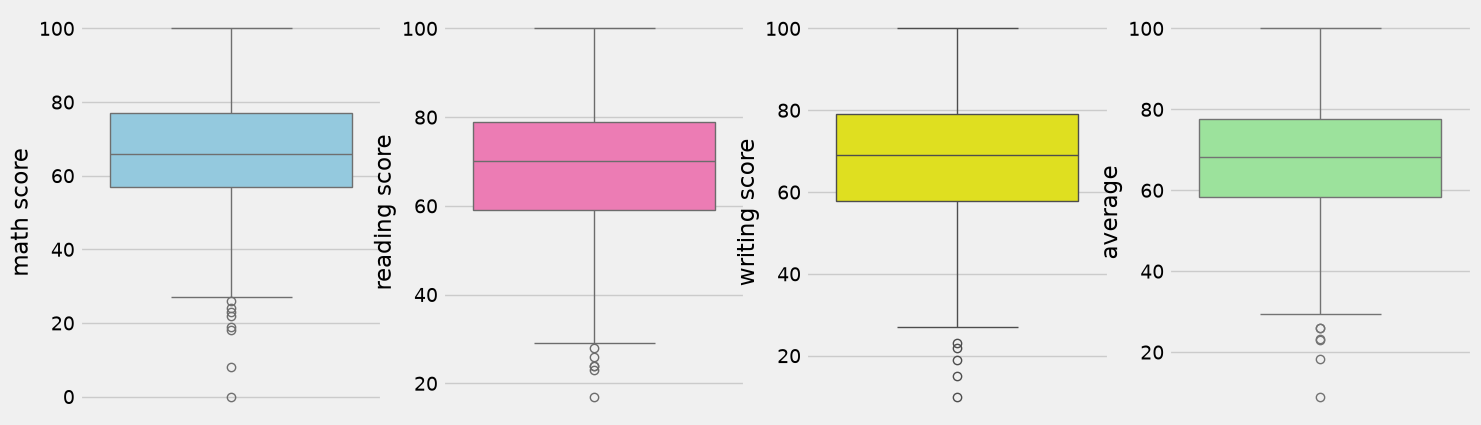

In [90]:
plt.subplots(1,4,figsize=(16,5))
plt.subplot(141)
sns.boxplot(df['math score'],color= 'skyblue')
plt.subplot(142)
sns.boxplot(df['reading score'], color='hotpink')

plt.subplot(143)
sns.boxplot(df['writing score'], color='yellow')

plt.subplot(144)
sns.boxplot(df['average'], color='lightgreen')
plt.show()

### 4.4.7 MUTIVARIATE ANALYSIS USING PAIRPLOT

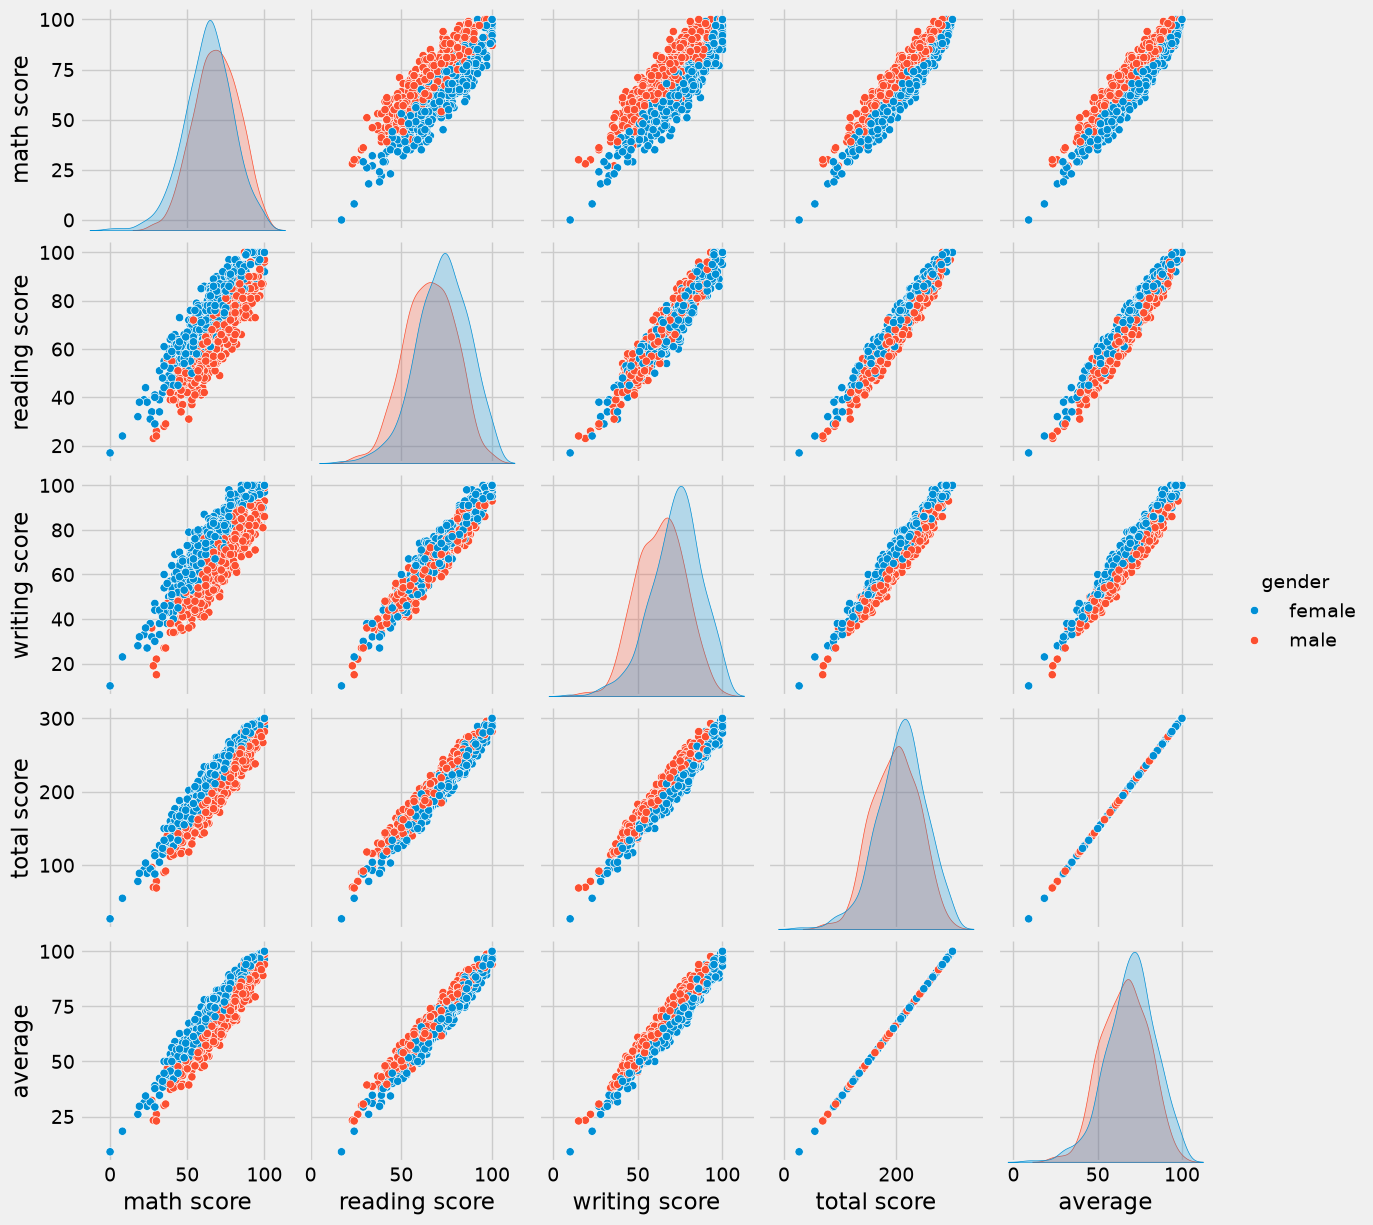

In [91]:
sns.pairplot(df,hue='gender')
plt.show()

* From the above plot it is clear that all the scores increase linearly with each other.

### 5. Conclusions
* Student's Performance is related with lunch, race, parental level education
* Females lead in pass percentage and also are top-scorers
* Student's Performance is not much related with test preparation course
* Finishing preparation course is benefitial.